In [2]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import get_scorer_names
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.compose import make_column_selector
from sklearn import set_config

In [3]:
df_train=pd.read_csv('data/train.csv')
df_test=pd.read_csv('data/test.csv')

In [4]:
le=LabelEncoder()

X=df_train.drop(columns=['health_condition'])
y = le.fit_transform(df_train['health_condition']) 
test_ids = df_test['id'].copy()

In [5]:
def features(df):
    df=df.copy()
    df=df.drop(columns='id')
    df['stress_level_NaN']=df['stress_level'].isna().astype(int)
    df['sleep_duration_NaN']=df['sleep_duration'].isna().astype(int)
    df['physical_activity_level_NaN']=df['physical_activity_level'].isna().astype(int)
    df['smoking_alcohol_NaN']=df['smoking_alcohol'].isna().astype(int)
    df['calorie_expenditure_NaN']=df['calorie_expenditure'].isna().astype(int)
    df['water_intake_NaN']=df['water_intake'].isna().astype(int)


    df['eau_normal'] = (2 - df['water_intake']).clip(lower=0)    
    df['BMI_normal'] = ((df['bmi'] > 18.5) & (df['bmi'] < 25)).astype(int)
    df['heart_normal'] = ((df['heart_rate'] > 50) & (df['heart_rate'] < 70)).astype(int)
    df['heart_dif']=abs(df['heart_rate']-60)
    df['step_dif']=(10000-df['step_count']).clip(lower=0)
    df['BMI_dif']=abs(df['bmi']-22)
    df['sleep_dif']=abs(df['sleep_duration']-8)
    df['riskscore']=((df['sleep_duration'] < 6).astype(int)+ (df['stress_level'] == 'high').astype(int)+ (df['physical_activity_level'] == 'sedentary').astype(int))
    return df

features_eng=FunctionTransformer(features)

In [6]:
X=features(X)

In [7]:
ord_cols=['sleep_quality','stress_level','smoking_alcohol','physical_activity_level']

obj_cols=X.select_dtypes(include=['object']).columns
cat_cols=[c for c in obj_cols if c not in ord_cols]

bool_cols=X.select_dtypes(include=['bool']).columns
num_cols=X.select_dtypes(include=['number']).columns
num_cols = [c for c in num_cols if c != 'id']

In [8]:
ordi_scales={
    'sleep_quality':['poor','average','good'],
    'stress_level':['high','medium','low'],
    'smoking_alcohol':['yes','occasional','no'],
    'physical_activity_level':['sedentary', 'moderate', 'active']
}

In [9]:
ordinal_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('OrdinalEncoder',OrdinalEncoder(categories=[ordi_scales[c] for c in ord_cols]))
])

cat_pipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('OneHotEncoder',OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe=Pipeline([('imputer',SimpleImputer(strategy='median'))
])

In [10]:
preprocessor = ColumnTransformer([
    ('ordinal_pipe', ordinal_pipe, ord_cols),
    ('cat_pipe', cat_pipe, cat_cols),
    ('num_pipe', num_pipe, num_cols),
])

logistic_pipe=Pipeline([
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('logistic',LogisticRegression(random_state=42,max_iter=1000,class_weight='balanced'))])

In [11]:
scores=cross_val_score(logistic_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("LogisticRegression :", scores.mean(), "+/-", scores.std())

KeyboardInterrupt: 

avant FE : 0.8568707209014267
après FE : 0.8568707209014267

In [29]:
random_pipe=Pipeline([
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('randomforest',RandomForestClassifier(random_state=42,class_weight='balanced',n_jobs=-1))])

In [30]:
scores=cross_val_score(random_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("RandomForest :", scores.mean(), "+/-", scores.std())

RandomForest : 0.9257910863569057 +/- 0.0015855247231418362


avant FE :
après FE : 

In [11]:
light_pipe=Pipeline([
('preprocessor',preprocessor),
('scaler',StandardScaler()),
('lgbm',LGBMClassifier(random_state=42,class_weight='balanced',n_jobs=1,verbose=-1))])


In [ ]:
scores=cross_val_score(light_pipe,X,y,cv=5,scoring='balanced_accuracy')
print("LightGBM :", scores.mean(), "+/-", scores.std())

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM : 0.9497866641357355 +/- 0.0005957542854067499


In [12]:
param_dist = {
    'lgbm__n_estimators': randint(300, 500),
    'lgbm__learning_rate': loguniform(0.01, 0.1),
    'lgbm__num_leaves': randint(20, 120),
    'lgbm__max_depth': randint(3, 12),
    'lgbm__min_child_samples': randint(10, 100),
    'lgbm__subsample': uniform(0.7, 0.3),          # 0.7 à 1.0
    'lgbm__colsample_bytree': uniform(0.7, 0.3),
    'lgbm__reg_alpha': loguniform(1e-3, 10),
    'lgbm__reg_lambda': loguniform(1e-3, 10),
}

param_grid = {
    'lgbm__n_estimators': [300, 600, 800, 1200],
    'lgbm__learning_rate': np.logspace(-2, -1, 5),
    'lgbm__num_leaves': [20,60,120],
}

In [16]:
import time
t = time.time()
light_pipe.fit(X, y)
print("temps 1 modèle:", time.time() - t)

temps 1 modèle: 18.071122407913208


In [13]:
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=100000, random_state=42, stratify=y)

In [22]:
import time
t = time.time()
light_pipe.fit(X_sample, y_sample)
print("temps 1 modèle:", time.time() - t)

temps 1 modèle: 0.8579039573669434


In [ ]:
grid=GridSearchCV(light_pipe,param_grid,cv=5,scoring='balanced_accuracy',n_jobs=-1)
grid.fit(X_sample,y_sample)

print('meilleurs paramètres : ',grid.best_params_)
print('meilleur score',grid.best_score_)

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/skle

meilleurs paramètres :  {'lgbm__learning_rate': np.float64(0.01), 'lgbm__n_estimators': 300, 'lgbm__num_leaves': 20}
meilleur score 0.9074591061191153


In [29]:
best_params = grid.best_params_
final_lgbm = light_pipe.set_params(**best_params)   # applique les meilleurs params
scores = cross_val_score(final_lgbm, X, y, cv=5, scoring='balanced_accuracy', n_jobs=32)
print("Score final sur dataset complet :", scores.mean())

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Score final sur dataset complet : 0.9070059089513351


In [ ]:
Randomgrid=RandomizedSearchCV(light_pipe,param_dist,n_iter=100,cv=5,scoring='balanced_accuracy',n_jobs=128)

Randomgrid.fit(X_sample,y_sample)

print('meilleurs paramètres : ',Randomgrid.best_params_)
print('meilleur score',Randomgrid.best_score_)

In [ ]:
best_params = Randomgrid.best_params_
final_lgbm = light_pipe.set_params(**best_params)
scores = cross_val_score(final_lgbm, X, y, cv=5, scoring='balanced_accuracy', n_jobs=32)
print("Score final sur dataset complet :", scores.mean())

/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Score final sur dataset complet : 0.94843239696865


/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/python/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


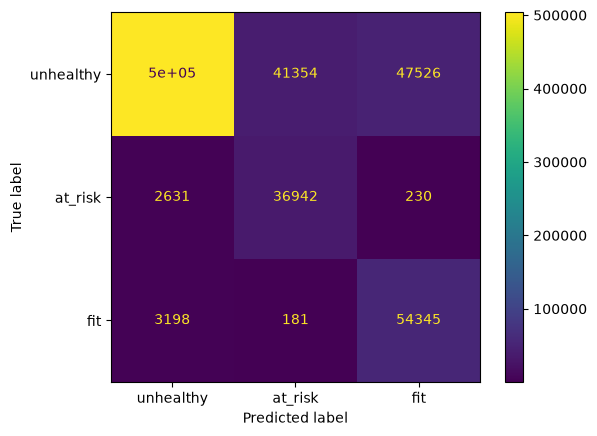

In [ ]:
y_pred=cross_val_predict(final_lgbm,X,y,cv=5,n_jobs=5)
ConfusionMatrixDisplay.from_predictions(y,y_pred,display_labels=['unhealthy','at_risk','fit'])

In [ ]:
final_lgbm.fit(X,y)
df_test=features(df_test)
predictions = final_lgbm.predict(df_test)
soumission = pd.DataFrame({ 'id': test_ids,
'health_condition': predictions
})

NameError: name 'final_lgbm' is not defined

In [ ]:
health_map = {0:'unhealthy', 1:'at-risk',2:'fit'}
soumission['health_condition'] = soumission['health_condition'].map(health_map)

soumission.to_csv('soumission_with_GBM_tuned.csv', index=False)